In [3]:
import requests
import pandas as pd
import os

url = "https://open.er-api.com/v6/latest/USD"
response = requests.get(url)
data = response.json()

brl_rate = data["rates"]["BRL"]
print(f"USD to BRL Rate: {brl_rate}")

df = pd.DataFrame([{
    "base_currency": "USD",
    "target_currency": "BRL",
    "exchange_rate": brl_rate,
    "last_updated": data["time_last_update_utc"]
}])

# Save in same folder as your CSVs
save_path = os.getcwd() + "\\exchange_rate_api.csv"
df.to_csv(save_path, index=False)
print(f"Saved at: {save_path}")

USD to BRL Rate: 4.990919
Saved at: C:\Users\jadha\task 2\exchange_rate_api.csv


In [7]:
import pandas as pd
import numpy as np
import os

path = r"C:\Users\jadha\task 2\\"

# Load original files
orders = pd.read_csv(path + "olist_orders_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")

print("Loaded ✅")

# Clean
orders.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
order_items.drop_duplicates(inplace=True)

orders['order_approved_at'].fillna(orders['order_approved_at'].mode()[0], inplace=True)
orders['order_delivered_carrier_date'].fillna('Unknown', inplace=True)
orders['order_delivered_customer_date'].fillna('Unknown', inplace=True)

products['product_category_name'].fillna('unknown', inplace=True)
products.fillna(0, inplace=True)

reviews['review_comment_title'].fillna('No Title', inplace=True)
reviews['review_comment_message'].fillna('No Comment', inplace=True)

# Fix dates
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Remove outliers
Q1 = payments['payment_value'].quantile(0.25)
Q3 = payments['payment_value'].quantile(0.75)
IQR = Q3 - Q1
payments_clean = payments[
    (payments['payment_value'] >= Q1 - 1.5*IQR) &
    (payments['payment_value'] <= Q3 + 1.5*IQR)
]

# Save cleaned files
orders.to_csv(path + "orders_clean.csv", index=False)
payments_clean.to_csv(path + "payments_clean.csv", index=False)
products.to_csv(path + "products_clean.csv", index=False)
reviews.to_csv(path + "reviews_clean.csv", index=False)

print("All cleaned files saved ✅")
print("Files in folder:", os.listdir(path))

Loaded ✅
All cleaned files saved ✅
Files in folder: ['.ipynb_checkpoints', 'exchange_rate_api.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'orders_clean.csv', 'payments_clean.csv', 'products_clean.csv', 'product_category_name_translation.csv', 'reviews_clean.csv', 'Task 2 .ipynb']


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

path = r"C:\Users\jadha\task 2\\"

orders = pd.read_csv(path + "orders_clean.csv")
payments = pd.read_csv(path + "payments_clean.csv")
products = pd.read_csv(path + "products_clean.csv")
reviews = pd.read_csv(path + "reviews_clean.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
category = pd.read_csv(path + "product_category_name_translation.csv")

date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print("EDA Data Loaded ✅")

EDA Data Loaded ✅


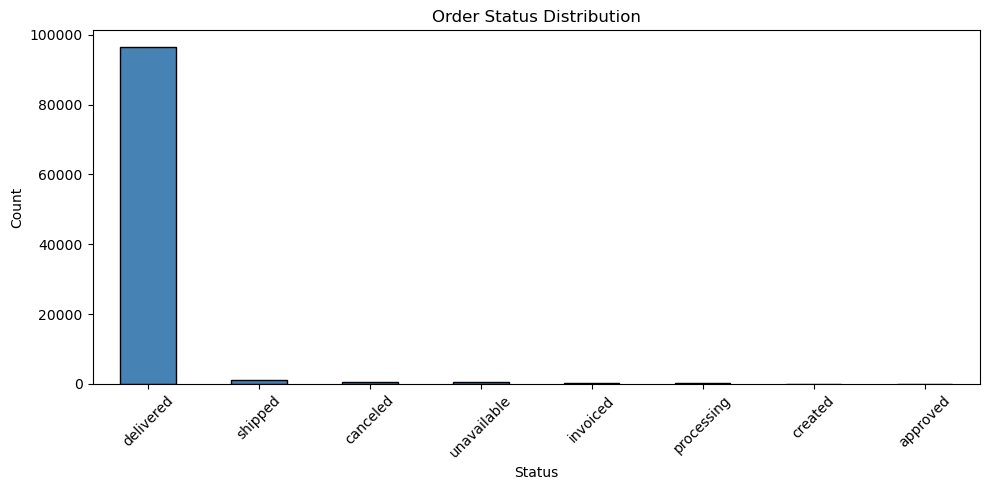

Plot 1 done ✅


In [13]:
plt.figure(figsize=(10,5))
orders['order_status'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(path + "plot1_order_status.png")
plt.show()
print("Plot 1 done ✅")

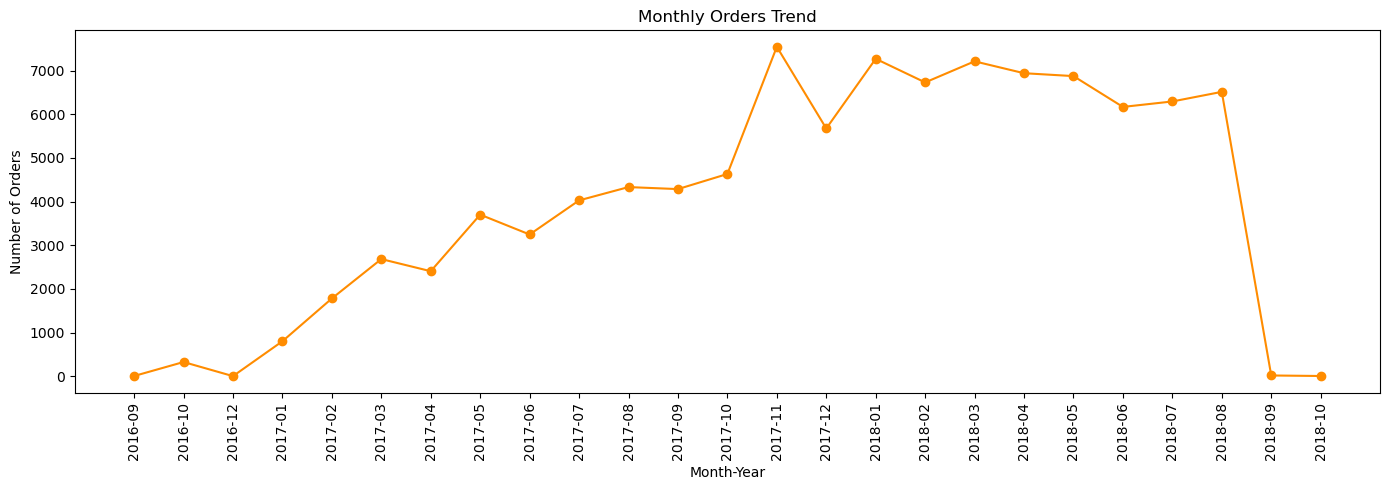

Plot 2 done ✅


In [15]:
orders['month_year'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('month_year').size().reset_index(name='order_count')

plt.figure(figsize=(14,5))
plt.plot(monthly_orders['month_year'].astype(str), monthly_orders['order_count'], marker='o', color='darkorange')
plt.title('Monthly Orders Trend')
plt.xlabel('Month-Year')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(path + "plot2_monthly_trend.png")
plt.show()
print("Plot 2 done ✅")

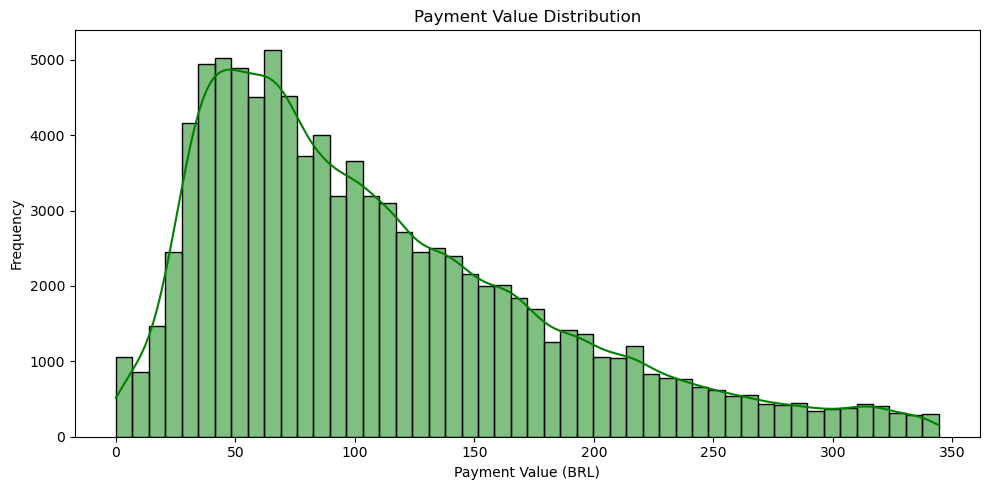

Plot 3 done ✅


In [17]:
plt.figure(figsize=(10,5))
sns.histplot(payments['payment_value'], bins=50, kde=True, color='green')
plt.title('Payment Value Distribution')
plt.xlabel('Payment Value (BRL)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(path + "plot3_payment_distribution.png")
plt.show()
print("Plot 3 done ✅")

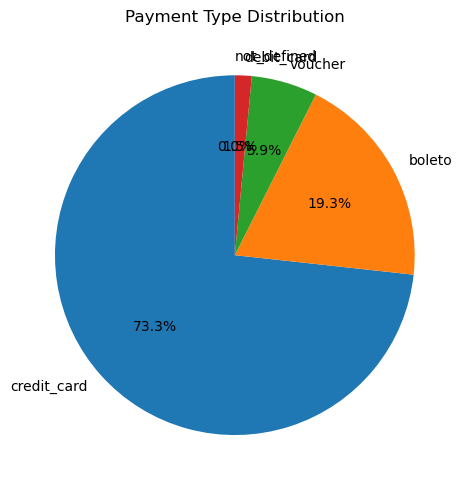

Plot 4 done ✅


In [19]:
plt.figure(figsize=(8,5))
payments['payment_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Payment Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig(path + "plot4_payment_type.png")
plt.show()
print("Plot 4 done ✅")

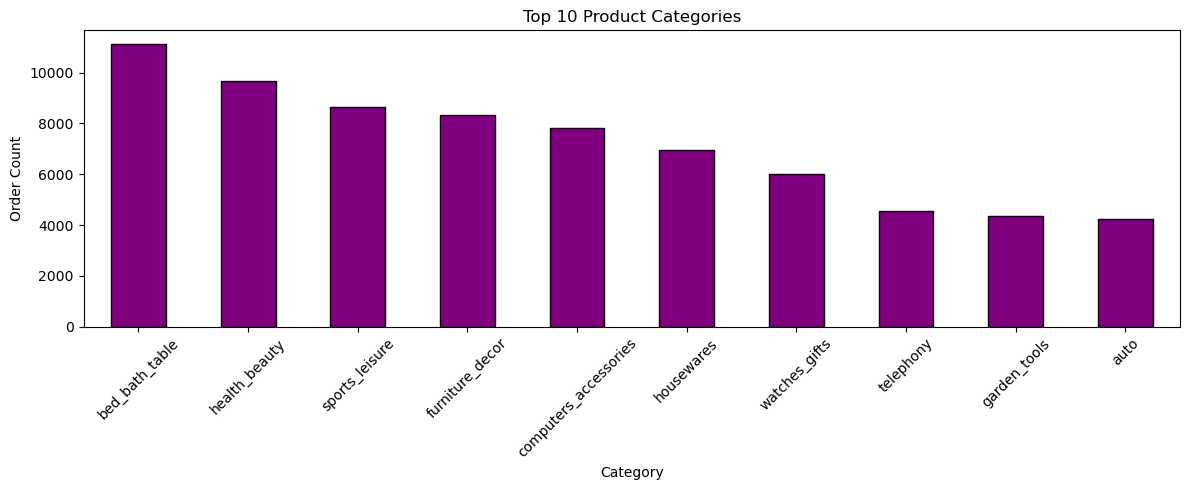

Plot 5 done ✅


In [21]:
merged = order_items.merge(products, on='product_id', how='left')
merged = merged.merge(category, on='product_category_name', how='left')

top_categories = merged['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(12,5))
top_categories.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(path + "plot5_top_categories.png")
plt.show()
print("Plot 5 done ✅")

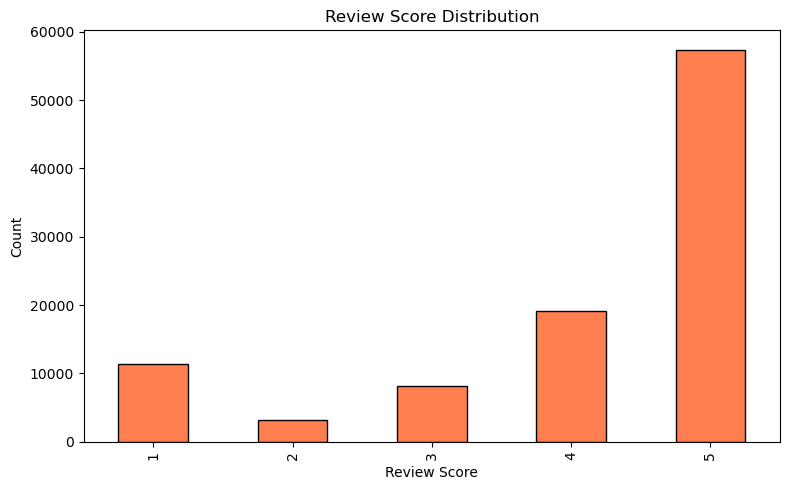

Plot 6 done ✅


In [23]:
plt.figure(figsize=(8,5))
reviews['review_score'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(path + "plot6_review_scores.png")
plt.show()
print("Plot 6 done ✅")

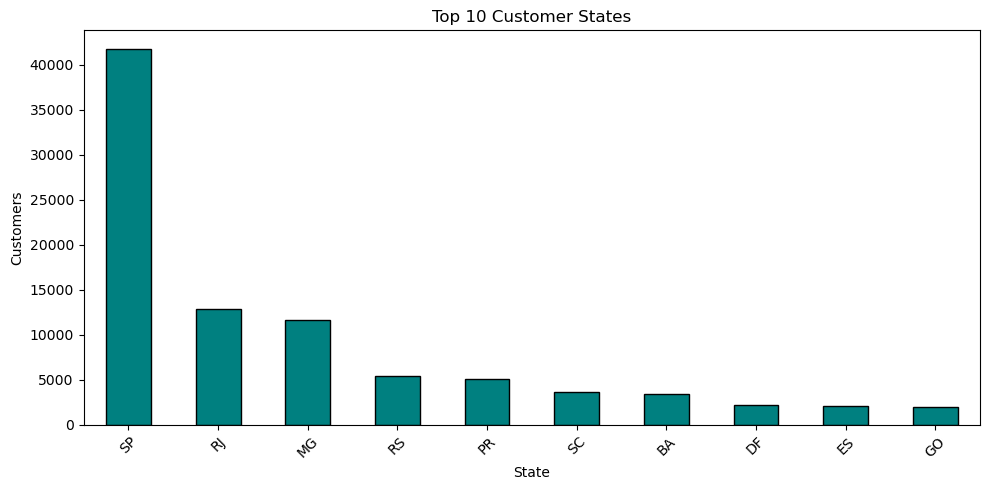

Plot 7 done ✅


In [25]:
top_states = customers['customer_state'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Customer States')
plt.xlabel('State')
plt.ylabel('Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(path + "plot7_customer_states.png")
plt.show()
print("Plot 7 done ✅")

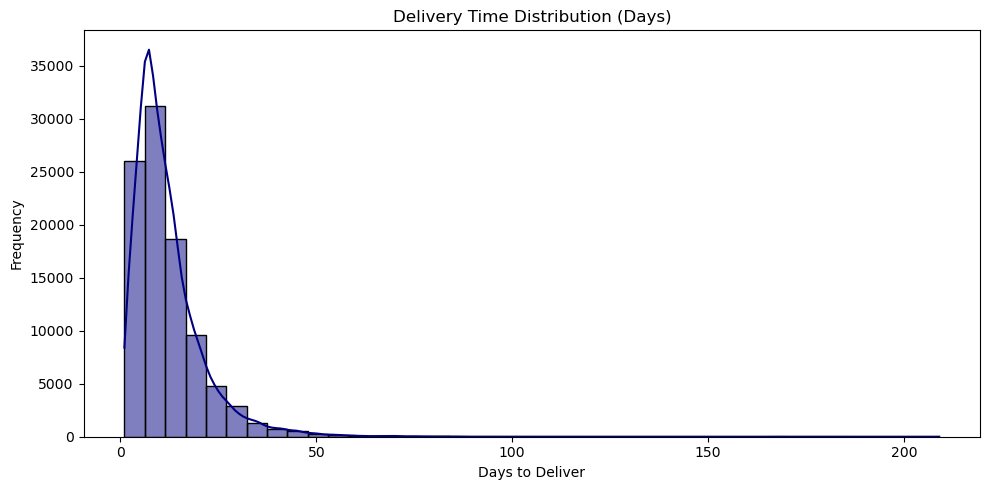

Plot 8 done ✅


In [27]:
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders_delivered = orders[orders['delivery_days'] > 0]

plt.figure(figsize=(10,5))
sns.histplot(orders_delivered['delivery_days'], bins=40, kde=True, color='navy')
plt.title('Delivery Time Distribution (Days)')
plt.xlabel('Days to Deliver')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(path + "plot8_delivery_time.png")
plt.show()
print("Plot 8 done ✅")

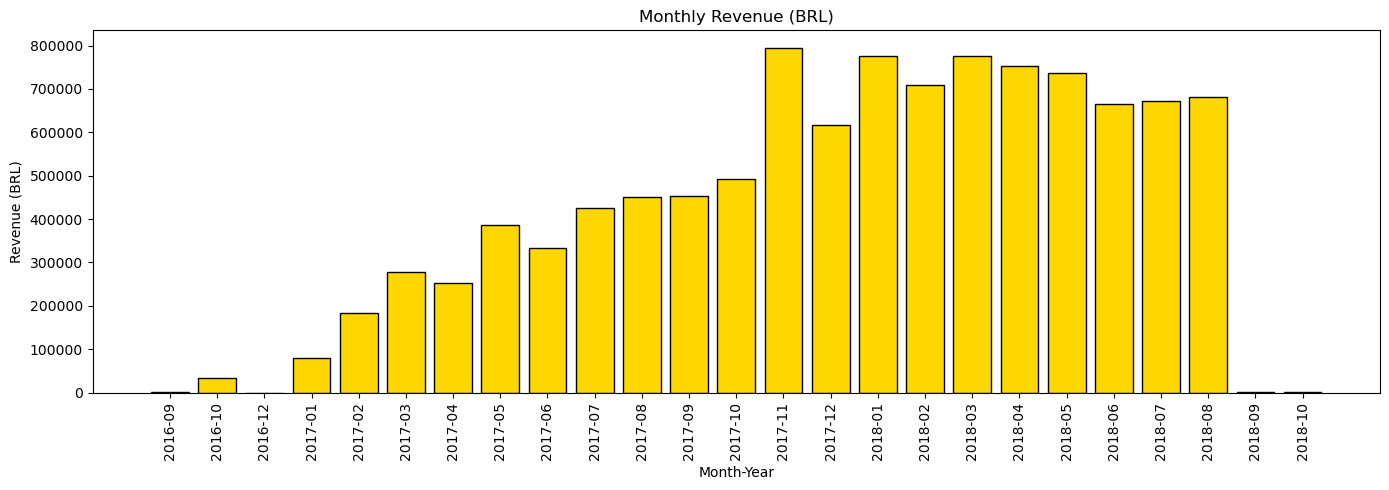

Plot 9 done ✅


In [29]:
orders_payments = orders.merge(payments, on='order_id', how='left')
orders_payments['month_year'] = orders_payments['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = orders_payments.groupby('month_year')['payment_value'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.bar(monthly_revenue['month_year'].astype(str), monthly_revenue['payment_value'], color='gold', edgecolor='black')
plt.title('Monthly Revenue (BRL)')
plt.xlabel('Month-Year')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(path + "plot9_monthly_revenue.png")
plt.show()
print("Plot 9 done ✅")

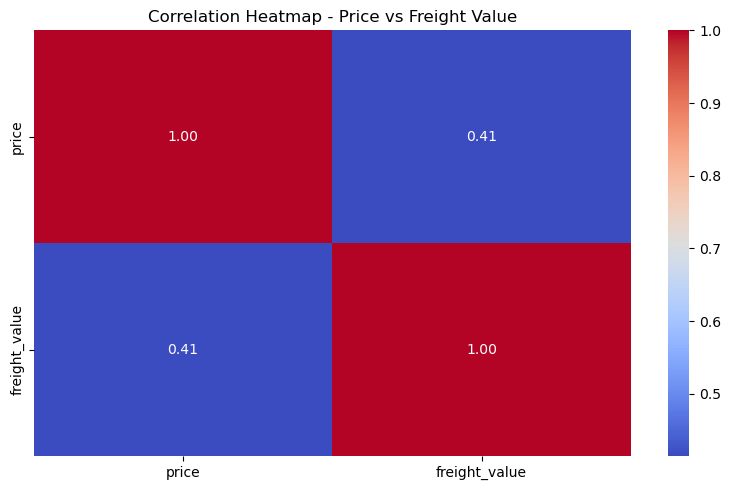

Plot 10 done ✅


In [33]:
num_df = order_items[['price','freight_value']].copy()

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Price vs Freight Value')
plt.tight_layout()
plt.savefig(path + "plot10_correlation_heatmap.png")
plt.show()
print("Plot 10 done ✅")

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

path = r"C:\Users\jadha\task 2\\"

orders = pd.read_csv(path + "orders_clean.csv")
payments = pd.read_csv(path + "payments_clean.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
reviews = pd.read_csv(path + "reviews_clean.csv")

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

print("KPI Data Loaded ✅")

KPI Data Loaded ✅


In [37]:
total_revenue = payments['payment_value'].sum()
print(f"KPI 1 - Total Revenue: BRL {total_revenue:,.2f}")

KPI 1 - Total Revenue: BRL 10,555,508.91


In [39]:
order_revenue = payments.groupby('order_id')['payment_value'].sum()
aov = order_revenue.mean()
print(f"KPI 2 - Average Order Value (AOV): BRL {aov:,.2f}")

KPI 2 - Average Order Value (AOV): BRL 115.23


In [41]:
customer_orders = orders.merge(payments, on='order_id', how='left')
customer_orders = customer_orders.merge(customers, on='customer_id', how='left')

clv = customer_orders.groupby('customer_unique_id')['payment_value'].sum()
print(f"KPI 3 - Average CLV: BRL {clv.mean():,.2f}")
print(f"KPI 3 - Max CLV: BRL {clv.max():,.2f}")
print(f"KPI 3 - Top 5 Customers by CLV:\n{clv.sort_values(ascending=False).head()}")

KPI 3 - Average CLV: BRL 109.84
KPI 3 - Max CLV: BRL 1,338.41
KPI 3 - Top 5 Customers by CLV:
customer_unique_id
1033eef37a760a832f9b2332ce23fdc5    1338.41
ca77025e7201e3b30c44b472ff346268    1122.72
dc813062e0fc23409cd255f7f53c7074    1094.63
7f6fd66526ed914998d483cff9b7bdd7    1025.71
be74c431147c32ab2d7c7cef5e4a995f    1020.00
Name: payment_value, dtype: float64


In [43]:
customer_order_count = customer_orders.groupby('customer_unique_id')['order_id'].nunique()
churned = (customer_order_count == 1).sum()
total_customers = customer_order_count.count()
churn_rate = (churned / total_customers) * 100
print(f"KPI 4 - Churn Rate: {churn_rate:.2f}%")
print(f"         One-time buyers: {churned} out of {total_customers}")

KPI 4 - Churn Rate: 96.88%
         One-time buyers: 93099 out of 96096


In [45]:
retention_rate = 100 - churn_rate
print(f"KPI 5 - Retention Rate: {retention_rate:.2f}%")

KPI 5 - Retention Rate: 3.12%


In [47]:
customer_orders['month_year'] = customer_orders['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = customer_orders.groupby('month_year')['payment_value'].sum().reset_index()
monthly_sales['growth_rate'] = monthly_sales['payment_value'].pct_change() * 100

print("KPI 6 - Monthly Sales Growth Rate:")
print(monthly_sales[['month_year','payment_value','growth_rate']].tail(10))

KPI 6 - Monthly Sales Growth Rate:
   month_year  payment_value  growth_rate
15    2018-01      775658.97    25.592454
16    2018-02      708344.13    -8.678407
17    2018-03      776744.11     9.656321
18    2018-04      751887.31    -3.200127
19    2018-05      736756.25    -2.012411
20    2018-06      664745.18    -9.774070
21    2018-07      671056.77     0.949475
22    2018-08      682378.97     1.687219
23    2018-09        1758.89   -99.742241
24    2018-10         589.67   -66.474879


In [49]:
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
avg_delivery = orders[orders['delivery_days'] > 0]['delivery_days'].mean()
print(f"KPI 7 - Average Delivery Time: {avg_delivery:.2f} days")

KPI 7 - Average Delivery Time: 12.10 days


In [51]:
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['on_time'] = delivered['order_delivered_customer_date'] <= delivered['order_estimated_delivery_date']
on_time_rate = delivered['on_time'].mean() * 100
print(f"KPI 8 - On-Time Delivery Rate: {on_time_rate:.2f}%")

KPI 8 - On-Time Delivery Rate: 91.88%


In [53]:
avg_review = reviews['review_score'].mean()
print(f"KPI 9 - Average Review Score: {avg_review:.2f} / 5.0")

KPI 9 - Average Review Score: 4.09 / 5.0


In [55]:
cancelled = (orders['order_status'] == 'canceled').sum()
total_orders = len(orders)
cancel_rate = (cancelled / total_orders) * 100
print(f"KPI 10 - Order Cancellation Rate: {cancel_rate:.2f}%")
print(f"          Cancelled Orders: {cancelled} out of {total_orders}")

KPI 10 - Order Cancellation Rate: 0.63%
          Cancelled Orders: 625 out of 99441


In [57]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue (BRL)',
        'Average Order Value (BRL)',
        'Average CLV (BRL)',
        'Churn Rate (%)',
        'Retention Rate (%)',
        'Avg Delivery Time (days)',
        'On-Time Delivery Rate (%)',
        'Avg Review Score (/5)',
        'Cancellation Rate (%)'
    ],
    'Value': [
        round(total_revenue, 2),
        round(aov, 2),
        round(clv.mean(), 2),
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(avg_delivery, 2),
        round(on_time_rate, 2),
        round(avg_review, 2),
        round(cancel_rate, 2)
    ]
})

print("\n========== BUSINESS KPI SUMMARY ==========")
print(kpi_summary.to_string(index=False))

kpi_summary.to_csv(path + "kpi_summary.csv", index=False)
print("\nKPI Summary saved ✅")


========== BUSINESS KPI SUMMARY ==========
                      KPI       Value
      Total Revenue (BRL) 10555508.91
Average Order Value (BRL)      115.23
        Average CLV (BRL)      109.84
           Churn Rate (%)       96.88
       Retention Rate (%)        3.12
 Avg Delivery Time (days)       12.10
On-Time Delivery Rate (%)       91.88
    Avg Review Score (/5)        4.09
    Cancellation Rate (%)        0.63

KPI Summary saved ✅


In [59]:
import sqlite3
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

path = r"C:\Users\jadha\task 2\\"

# Load all files
orders = pd.read_csv(path + "orders_clean.csv")
payments = pd.read_csv(path + "payments_clean.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
reviews = pd.read_csv(path + "reviews_clean.csv")
products = pd.read_csv(path + "products_clean.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
category = pd.read_csv(path + "product_category_name_translation.csv")

# Create SQLite DB
conn = sqlite3.connect(path + "olist.db")

# Load into DB
orders.to_sql("orders", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
sellers.to_sql("sellers", conn, if_exists="replace", index=False)
category.to_sql("category", conn, if_exists="replace", index=False)

print("SQLite DB created & all tables loaded ✅")

SQLite DB created & all tables loaded ✅


In [61]:
q1 = pd.read_sql_query("""
    SELECT 
        o.order_id,
        c.customer_city,
        c.customer_state,
        o.order_status,
        p.payment_value,
        p.payment_type
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN payments p ON o.order_id = p.order_id
    LIMIT 10
""", conn)

print("Query 1 - Orders with Customer & Payment Info:")
print(q1)

Query 1 - Orders with Customer & Payment Info:
                           order_id            customer_city customer_state  \
0  e481f51cbdc54678b7cc49136f2d6af7                sao paulo             SP   
1  e481f51cbdc54678b7cc49136f2d6af7                sao paulo             SP   
2  e481f51cbdc54678b7cc49136f2d6af7                sao paulo             SP   
3  53cdb2fc8bc7dce0b6741e2150273451                barreiras             BA   
4  47770eb9100c2d0c44946d9cf07ec65d               vianopolis             GO   
5  949d5b44dbf5de918fe9c16f97b45f8a  sao goncalo do amarante             RN   
6  ad21c59c0840e6cb83a9ceb5573f8159              santo andre             SP   
7  a4591c265e18cb1dcee52889e2d8acc3             congonhinhas             PR   
8  136cce7faa42fdb2cefd53fdc79a6098               santa rosa             RS   
9  6514b8ad8028c9f2cc2374ded245783f                nilopolis             RJ   

  order_status  payment_value payment_type  
0    delivered          18.12  credit_

In [63]:
q2 = pd.read_sql_query("""
    SELECT 
        c.customer_city,
        c.customer_state,
        ROUND(SUM(p.payment_value), 2) AS total_revenue,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN payments p ON o.order_id = p.order_id
    GROUP BY c.customer_city, c.customer_state
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)

print("Query 2 - Top 10 Revenue Cities:")
print(q2)

Query 2 - Top 10 Revenue Cities:
    customer_city customer_state  total_revenue  total_orders
0       sao paulo             SP     1524671.87         14550
1  rio de janeiro             RJ      748697.20          6299
2  belo horizonte             MG      298849.21          2589
3        brasilia             DF      228981.49          1957
4        curitiba             PR      157869.57          1397
5    porto alegre             RS      155295.31          1272
6        campinas             SP      144105.07          1340
7        salvador             BA      137428.61          1131
8       guarulhos             SP      122579.60          1125
9         niteroi             RJ       96639.19           794


In [65]:
q3 = pd.read_sql_query("""
    SELECT 
        customer_id,
        total_spent
    FROM (
        SELECT 
            o.customer_id,
            ROUND(SUM(p.payment_value), 2) AS total_spent
        FROM orders o
        JOIN payments p ON o.order_id = p.order_id
        GROUP BY o.customer_id
    ) customer_spend
    WHERE total_spent > (
        SELECT AVG(payment_value) FROM payments
    )
    ORDER BY total_spent DESC
    LIMIT 10
""", conn)

print("Query 3 - Customers Above Average Spend:")
print(q3)

Query 3 - Customers Above Average Spend:
                        customer_id  total_spent
0  f959b7bc834045511217e6410985963f      1338.41
1  3118aefef04e5e97d0e339cd75d6d775      1025.71
2  6f241d5bbb142b6f764387c8c270645a      1020.00
3  de832e8dbb1f588a47013e53feaa67cc       740.76
4  85ed641fe825f188f1a67b317b5f540c       666.71
5  a99b2128d3db96e838381fe6042cdee6       622.08
6  911035bc0dcc0c5ee9580cbe3e59ed06       599.26
7  d3e82ccec3cb5f956a38d96c057ceaae       598.75
8  03b243d7ac6a467982044dd9dddb4d68       583.15
9  5bb40f4d5a4371842ecc05e3b4475dc1       567.59


In [67]:
q4 = pd.read_sql_query("""
    SELECT 
        oi.product_id,
        cat.product_category_name_english AS category,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        COUNT(oi.order_id) AS total_orders
    FROM order_items oi
    LEFT JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category cat ON p.product_category_name = cat.product_category_name
    WHERE oi.product_id IN (
        SELECT product_id 
        FROM order_items 
        GROUP BY product_id 
        HAVING COUNT(order_id) > 50
    )
    GROUP BY oi.product_id
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)

print("Query 4 - Top Products by Revenue:")
print(q4)

Query 4 - Top Products by Revenue:
                         product_id               category  total_revenue  \
0  bb50f2e236e5eea0100680137654686c          health_beauty       63885.00   
1  6cdd53843498f92890544667809f1595          health_beauty       54730.20   
2  d1c427060a0f73f6b889a5c7c61f2ac4  computers_accessories       47214.51   
3  99a4788cb24856965c36a24e339b6058         bed_bath_table       43025.56   
4  3dd2a17168ec895c781a9191c1e95ad7  computers_accessories       41082.60   
5  5f504b3a1c75b73d6151be81eb05bdc9             cool_stuff       37733.90   
6  53b36df67ebb7c41585e8d54d6772e08          watches_gifts       37683.42   
7  aca2eb7d00ea1a7b8ebd4e68314663af        furniture_decor       37608.90   
8  e0d64dcfaa3b6db5c54ca298ae101d05          watches_gifts       31786.82   
9  d285360f29ac7fd97640bf0baef03de0          watches_gifts       31623.81   

   total_orders  
0           195  
1           156  
2           343  
3           488  
4           274  
5        

In [69]:
q5 = pd.read_sql_query("""
    SELECT 
        month_year,
        total_revenue,
        RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
    FROM (
        SELECT 
            STRFTIME('%Y-%m', o.order_purchase_timestamp) AS month_year,
            ROUND(SUM(p.payment_value), 2) AS total_revenue
        FROM orders o
        JOIN payments p ON o.order_id = p.order_id
        GROUP BY month_year
    )
    ORDER BY revenue_rank
""", conn)

print("Query 5 - Monthly Revenue Rank:")
print(q5)

Query 5 - Monthly Revenue Rank:
   month_year  total_revenue  revenue_rank
0     2017-11      795216.87             1
1     2018-03      776744.11             2
2     2018-01      775658.97             3
3     2018-04      751887.31             4
4     2018-05      736756.25             5
5     2018-02      708344.13             6
6     2018-08      682378.97             7
7     2018-07      671056.77             8
8     2018-06      664745.18             9
9     2017-12      617599.98            10
10    2017-10      492343.49            11
11    2017-09      454259.10            12
12    2017-08      450671.01            13
13    2017-07      425606.32            14
14    2017-05      385922.09            15
15    2017-06      334376.01            16
16    2017-03      278518.19            17
17    2017-04      253380.70            18
18    2017-02      183833.39            19
19    2017-01       79036.40            20
20    2016-10       34553.25            21
21    2018-09        1

In [71]:
q6 = pd.read_sql_query("""
    SELECT 
        month_year,
        total_revenue,
        ROUND(SUM(total_revenue) OVER (ORDER BY month_year), 2) AS running_total
    FROM (
        SELECT 
            STRFTIME('%Y-%m', o.order_purchase_timestamp) AS month_year,
            ROUND(SUM(p.payment_value), 2) AS total_revenue
        FROM orders o
        JOIN payments p ON o.order_id = p.order_id
        GROUP BY month_year
    )
    ORDER BY month_year
""", conn)

print("Query 6 - Running Total Revenue:")
print(q6)

Query 6 - Running Total Revenue:
   month_year  total_revenue  running_total
0     2016-09         252.24         252.24
1     2016-10       34553.25       34805.49
2     2016-12          19.62       34825.11
3     2017-01       79036.40      113861.51
4     2017-02      183833.39      297694.90
5     2017-03      278518.19      576213.09
6     2017-04      253380.70      829593.79
7     2017-05      385922.09     1215515.88
8     2017-06      334376.01     1549891.89
9     2017-07      425606.32     1975498.21
10    2017-08      450671.01     2426169.22
11    2017-09      454259.10     2880428.32
12    2017-10      492343.49     3372771.81
13    2017-11      795216.87     4167988.68
14    2017-12      617599.98     4785588.66
15    2018-01      775658.97     5561247.63
16    2018-02      708344.13     6269591.76
17    2018-03      776744.11     7046335.87
18    2018-04      751887.31     7798223.18
19    2018-05      736756.25     8534979.43
20    2018-06      664745.18     9199724.61

In [73]:
q7 = pd.read_sql_query("""
    SELECT 
        customer_id,
        total_orders,
        total_spent,
        RANK() OVER (ORDER BY total_spent DESC) AS spend_rank,
        NTILE(4) OVER (ORDER BY total_spent DESC) AS spend_quartile
    FROM (
        SELECT 
            o.customer_id,
            COUNT(DISTINCT o.order_id) AS total_orders,
            ROUND(SUM(p.payment_value), 2) AS total_spent
        FROM orders o
        JOIN payments p ON o.order_id = p.order_id
        GROUP BY o.customer_id
    )
    ORDER BY spend_rank
    LIMIT 10
""", conn)

print("Query 7 - Customer Spend Ranking:")
print(q7)

Query 7 - Customer Spend Ranking:
                        customer_id  total_orders  total_spent  spend_rank  \
0  f959b7bc834045511217e6410985963f             1      1338.41           1   
1  3118aefef04e5e97d0e339cd75d6d775             1      1025.71           2   
2  6f241d5bbb142b6f764387c8c270645a             1      1020.00           3   
3  de832e8dbb1f588a47013e53feaa67cc             1       740.76           4   
4  85ed641fe825f188f1a67b317b5f540c             1       666.71           5   
5  a99b2128d3db96e838381fe6042cdee6             1       622.08           6   
6  911035bc0dcc0c5ee9580cbe3e59ed06             1       599.26           7   
7  d3e82ccec3cb5f956a38d96c057ceaae             1       598.75           8   
8  03b243d7ac6a467982044dd9dddb4d68             1       583.15           9   
9  5bb40f4d5a4371842ecc05e3b4475dc1             1       567.59          10   

   spend_quartile  
0               1  
1               1  
2               1  
3               1  
4      

In [75]:
q8 = pd.read_sql_query("""
    SELECT 
        seller_id,
        total_revenue,
        total_orders,
        ROUND(AVG(total_revenue) OVER (), 2) AS avg_seller_revenue,
        RANK() OVER (ORDER BY total_revenue DESC) AS seller_rank
    FROM (
        SELECT 
            oi.seller_id,
            ROUND(SUM(oi.price), 2) AS total_revenue,
            COUNT(DISTINCT oi.order_id) AS total_orders
        FROM order_items oi
        GROUP BY oi.seller_id
    )
    ORDER BY seller_rank
    LIMIT 10
""", conn)

print("Query 8 - Top Seller Performance:")
print(q8)

Query 8 - Top Seller Performance:
                          seller_id  total_revenue  total_orders  \
0  4869f7a5dfa277a7dca6462dcf3b52b2      229472.63          1132   
1  53243585a1d6dc2643021fd1853d8905      222776.05           358   
2  4a3ca9315b744ce9f8e9374361493884      200472.92          1806   
3  fa1c13f2614d7b5c4749cbc52fecda94      194042.03           585   
4  7c67e1448b00f6e969d365cea6b010ab      187923.89           982   
5  7e93a43ef30c4f03f38b393420bc753a      176431.87           336   
6  da8622b14eb17ae2831f4ac5b9dab84a      160236.57          1314   
7  7a67c85e85bb2ce8582c35f2203ad736      141745.53          1160   
8  1025f0e2d44d7041d6cf58b6550e0bfa      138968.55           915   
9  955fee9216a65b617aa5c0531780ce60      135171.70          1287   

   avg_seller_revenue  seller_rank  
0             4391.48            1  
1             4391.48            2  
2             4391.48            3  
3             4391.48            4  
4             4391.48           

In [77]:
q1.to_csv(path + "sql_q1_orders_customers.csv", index=False)
q2.to_csv(path + "sql_q2_top_cities.csv", index=False)
q3.to_csv(path + "sql_q3_high_spenders.csv", index=False)
q4.to_csv(path + "sql_q4_top_products.csv", index=False)
q5.to_csv(path + "sql_q5_monthly_rank.csv", index=False)
q6.to_csv(path + "sql_q6_running_total.csv", index=False)
q7.to_csv(path + "sql_q7_customer_rank.csv", index=False)
q8.to_csv(path + "sql_q8_seller_performance.csv", index=False)

conn.close()
print("All SQL results saved ✅")

All SQL results saved ✅


In [79]:
import pandas as pd
path = r"C:\Users\jadha\task 2\\"

files = {
    "orders_clean": "orders_clean.csv",
    "payments_clean": "payments_clean.csv",
    "order_items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "reviews_clean": "reviews_clean.csv",
    "products_clean": "products_clean.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category": "product_category_name_translation.csv"
}

with pd.ExcelWriter(path + "olist_complete.xlsx", engine='openpyxl') as writer:
    for sheet_name, file in files.items():
        df = pd.read_csv(path + file)
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Excel file created ✅")
print("File: olist_complete.xlsx")

Excel file created ✅
File: olist_complete.xlsx
